# Equity Duration – Robustness Measures

Three cross-sectional proxies for equity duration:
- **Shareholder Yield (SY):** (Dividends + Buybacks) / ME
- **Book-to-Market (B/M):** BE / ME
- **Earnings-to-Price (E/P):** NetIncome / ME

Input: `euro500_netpayout.parquet`  
Output: `EQDuration_Robustness.parquet`

## 1. Setup & Data Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

from plot_style import COLORS, set_global_plot_style, style_axes, save_figure as _ps_save_figure
from project_paths import BASE_DIR, DATA_DIR, GRAPH_DIR

set_global_plot_style()

# Graph-Unterordner für dieses Notebook
GRAPH_SUBDIR = GRAPH_DIR / "EQDuration_Robustness"
GRAPH_SUBDIR.mkdir(parents=True, exist_ok=True)

def save_figure(fig, name: str, dpi: int = 150):
    path = GRAPH_SUBDIR / f"{name}.png"
    _ps_save_figure(fig, path, dpi=dpi)
    print(f"Saved figure: {path}")


def save_parquet(df: pd.DataFrame, name: str):
    path = DATA_DIR / f"{name}.parquet"
    df.to_parquet(path, index=False)
    print(f"Saved: {path}")


def load_parquet(name: str) -> pd.DataFrame:
    path = DATA_DIR / f"{name}.parquet"
    return pd.read_parquet(path)


In [2]:
raw = load_parquet("euro500_netpayout").copy()

# --- Parse dates & identifiers ---
raw["firm_id"] = raw["firm_id"].astype(str).str.strip()

if "date" in raw.columns:
    raw["date"] = pd.to_datetime(raw["date"], errors="coerce")
    raw["year"] = raw["date"].dt.year
elif "effective_date" in raw.columns:
    raw["effective_date"] = pd.to_datetime(raw["effective_date"], errors="coerce")
    raw["year"] = raw["effective_date"].dt.year
elif "year" not in raw.columns:
    raise KeyError("Input needs date, effective_date, or year column")

raw["year"] = pd.to_numeric(raw["year"], errors="coerce").astype("Int64")

# Financials ausschließen — konsistent mit EQDuration_NetPayout
# Sektorspalte: trbc_sector (Thomson Reuters Business Classification)
# Financials = alle Einträge die "Financials" enthalten
if "trbc_sector" in raw.columns:
    _n_before = raw["firm_id"].nunique()
    _fin_mask = raw["trbc_sector"].astype(str).str.contains(
        "Financ", case=False, na=False
    )
    raw = raw[~_fin_mask].copy()
    _n_after = raw["firm_id"].nunique()
    print(f"Excluded Financials (trbc_sector): "
          f"{_fin_mask.sum():,} rows removed, "
          f"{_n_before - _n_after:,} firms removed "
          f"({_n_after:,} firms remaining)")
    print(f"Unique trbc_sector values after filter:")
    print(raw["trbc_sector"].value_counts().to_string())
else:
    print("WARNUNG: trbc_sector nicht gefunden — Financials nicht gefiltert.")

# --- Aggregate to annual: latest observation per firm-year ---
sort_col = "date" if "date" in raw.columns else "effective_date"
raw = raw.sort_values(["firm_id", "year", sort_col], na_position="first")
ann = raw.groupby(["firm_id", "year"], as_index=False).last()
ann["year"] = ann["year"].astype(int)

# --- Ensure CashSTInvst exists ---
if "CashSTInvst" not in ann.columns:
    ann["CashSTInvst"] = np.nan

# --- Lagged variables within firm ---
ann = ann.sort_values(["firm_id", "year"])
for col in ["BE", "Sales"]:
    if col in ann.columns:
        ann[f"{col}_lag1"] = ann.groupby("firm_id")[col].shift(1)

# ME_t = mcap_eur (already in EUR)
ann["ME_t"] = pd.to_numeric(ann["mcap_eur"], errors="coerce")

print(f"Shape (firm-year panel): {ann.shape}")
print(f"Firms: {ann['firm_id'].nunique():,}   Years: {sorted(ann['year'].unique())}")
print(f"Date range: {ann['year'].min()} – {ann['year'].max()}")

# --- Coverage diagnostics ---
cov_cols = ["ME_t", "BE", "NetIncome", "Dividends", "Buybacks", "CashSTInvst"]
cov = {c: ann[c].notna().sum() if c in ann.columns else 0 for c in cov_cols}
print("\nNon-null counts per key column:")
for c, n in cov.items():
    print(f"  {c:<16} {n:>6,}  ({100*n/len(ann):.1f}%)")

Excluded Financials (trbc_sector): 2,097 rows removed, 149 firms removed (946 firms remaining)
Unique trbc_sector values after filter:
trbc_sector
Industrials                                   2638
Consumer Cyclicals                            2249
Technology                                    1566
Basic Materials                               1435
Healthcare                                     987
Consumer Non-Cyclicals                         977
Real Estate                                    844
Utilities                                      792
Energy                                         592
Institutions, Associations & Organizations       6
Academic & Educational Services                  1
Shape (firm-year panel): (12073, 19)
Firms: 946   Years: [np.int64(1997), np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2

## 2. Shareholder Yield

Two variants:

$$
\text{SY}_{\text{gross}} = \frac{\text{Dividends} + \text{Buybacks}}{\text{ME}_t}
\qquad
\text{SY}_{\text{div\_only}} = \frac{\text{Dividends}}{\text{ME}_t}
$$

Sign convention: LSEG reports Dividends/Buybacks as positive outflows; `abs()` guards against
occasional sign flips in the source data.

In [3]:
def _winsorize_cross_section(series: pd.Series, groups: pd.Series,
                              lo: float = 0.01, hi: float = 0.99) -> pd.Series:
    """Winsorize at lo/hi quantiles cross-sectionally within each group."""
    out = series.copy().astype(float)
    for grp, idx in groups.groupby(groups).groups.items():
        vals = out.loc[idx]
        q_lo = vals.quantile(lo)
        q_hi = vals.quantile(hi)
        out.loc[idx] = vals.clip(lower=q_lo, upper=q_hi)
    return out


# --- Sign-safe payout components ---
div = pd.to_numeric(ann["Dividends"], errors="coerce").abs() if "Dividends" in ann.columns else pd.Series(np.nan, index=ann.index)
bb  = pd.to_numeric(ann["Buybacks"],  errors="coerce").abs() if "Buybacks"  in ann.columns else pd.Series(np.nan, index=ann.index)

# --- Shareholder Yield variants ---

# Variant 1: Gross (Dividends + Buybacks)
# fill_value=0 only where Dividends exist but Buybacks are missing —
# treats missing Buybacks as 'no repurchases' (conservative)
total_payout = div.add(bb, fill_value=0)
ann["SY_gross"] = total_payout / ann["ME_t"]

# Variant 2: Dividends only — higher coverage, more stable for early years
# and firms without buyback reporting
ann["SY_div_only"] = div / ann["ME_t"]

# SY_adj removed: CashSTInvst is not a direct equity issuance measure; Pearson(SY_adj, SY_gross)=0.033

# Mask where ME_t <= 0 or missing
me_invalid = ann["ME_t"].isna() | (ann["ME_t"] <= 0)
ann.loc[me_invalid, ["SY_gross", "SY_div_only"]] = np.nan

# Flag: Buybacks missing (cannot be safely imputed as 0)
ann["flag_sy_buybacks_missing"] = (div.notna() & bb.isna()).astype("Int8")

# --- Winsorize at 1%/99% by year ---
for col in ["SY_gross", "SY_div_only"]:
    ann[f"{col}_w"] = _winsorize_cross_section(ann[col], ann["year"])

ann["flag_sy_negative"] = (ann["SY_gross"] < 0).astype("Int8")

# --- Diagnostics ---
print("SY_gross descriptive stats:")
print(ann["SY_gross"].describe().round(4))
print(f"\nSY_div_only vs SY_gross coverage:")
print(f"  SY_gross    non-null: {ann['SY_gross'].notna().sum():,}  "
      f"({100*ann['SY_gross'].notna().mean():.1f}%)")
print(f"  SY_div_only non-null: {ann['SY_div_only'].notna().sum():,}  "
      f"({100*ann['SY_div_only'].notna().mean():.1f}%)")
print(f"\nBuybacks missing (flag_sy_buybacks_missing): "
      f"{ann['flag_sy_buybacks_missing'].sum():,} obs "
      f"({100*ann['flag_sy_buybacks_missing'].mean():.1f}%)")
print("\nCorrelation SY_gross vs SY_div_only "
      "(quantifies buyback contribution):")
_valid_sy = ann[["SY_gross", "SY_div_only"]].dropna()
print(f"  Pearson  = {_valid_sy['SY_gross'].corr(_valid_sy['SY_div_only']):.3f}")
print(f"\nNegative SY_gross: {ann['flag_sy_negative'].sum():,} ({100*ann['flag_sy_negative'].mean():.1f}%)")

SY_gross descriptive stats:
count    10764.0
mean      0.0561
std       0.3662
min          0.0
25%       0.0154
50%       0.0303
75%       0.0568
max      28.8692
Name: SY_gross, dtype: Float64

SY_div_only vs SY_gross coverage:
  SY_gross    non-null: 10,764  (89.2%)
  SY_div_only non-null: 9,913  (82.1%)

Buybacks missing (flag_sy_buybacks_missing): 3,214 obs (26.6%)

Correlation SY_gross vs SY_div_only (quantifies buyback contribution):
  Pearson  = 0.976

Negative SY_gross: 0 (0.0%)


> **Coverage note:** `SY_gross` uses `div.add(bb, fill_value=0)`, which produces a value
> whenever *at least one* of Dividends or Buybacks is non-null. `SY_div_only` is NaN whenever
> Dividends are missing, even if Buybacks are available. This is intentional: `SY_div_only`
> is the cleaner single-source measure, `SY_gross` the more inclusive one.

Saved figure: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/graphs/EQDuration_Robustness/sy_distribution.png


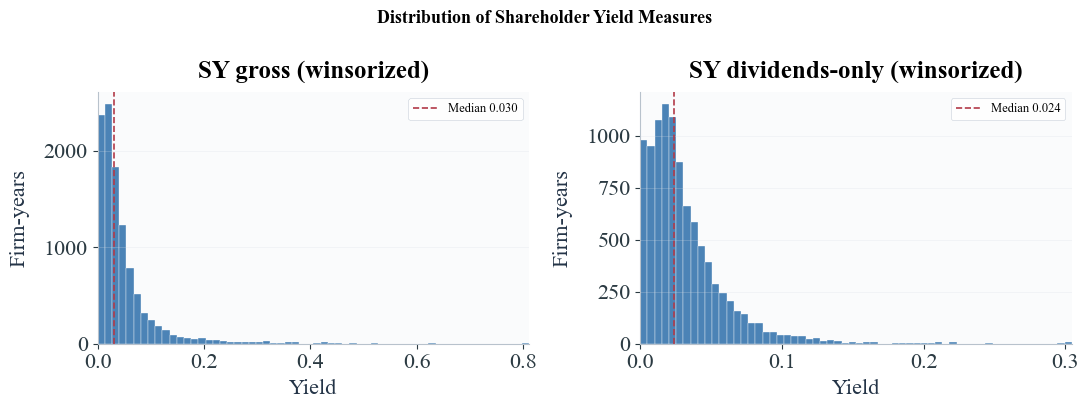

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, col, label in zip(
    axes,
    ["SY_gross_w", "SY_div_only_w"],
    ["SY gross (winsorized)", "SY dividends-only (winsorized)"],
):
    data = ann[col].dropna()
    ax.hist(data, bins=60, color=COLORS["blue"], edgecolor="white", linewidth=0.3, alpha=0.85)
    ax.axvline(data.median(), color=COLORS["accent"], linewidth=1.2, linestyle="--",
               label=f"Median {data.median():.3f}")
    ax.set_title(label)
    ax.set_xlabel("Yield")
    ax.set_ylabel("Firm-years")
    style_axes(ax)
    ax.legend(fontsize=9)

fig.suptitle("Distribution of Shareholder Yield Measures", y=1.01, fontsize=13, fontweight="semibold")
plt.tight_layout()
save_figure(fig, "sy_distribution")
plt.show()

## 3. Book-to-Market (B/M)

$$
\text{B/M}_{i,t} = \frac{\text{BE}_{i,t}}{\text{ME}_t}
$$

Requires $\text{BE} > 0$ and $\text{ME}_t > 0$.

In [5]:
be = pd.to_numeric(ann["BE"], errors="coerce") if "BE" in ann.columns else pd.Series(np.nan, index=ann.index)

bm_raw = be / ann["ME_t"]
# Require both BE > 0 and ME_t > 0
bm_raw = bm_raw.where((be > 0) & (ann["ME_t"] > 0))

ann["BM"] = bm_raw
ann["BM_w"] = _winsorize_cross_section(ann["BM"], ann["year"])

print("B/M descriptive stats:")
print(ann["BM"].describe().round(4))
print(f"\nNon-null B/M: {ann['BM'].notna().sum():,}")

# Correlation with SY_gross (expected: positive — both are short-duration proxies;
# value firms (high B/M) tend to pay out more (high SY), consistent with DSS)
valid = ann[["BM", "SY_gross"]].dropna()
corr = valid["BM"].corr(valid["SY_gross"])
print(f"\nCorr(B/M, SY_gross) = {corr:.3f}  (expected: positive — both are short-duration proxies)")

B/M descriptive stats:
count    11571.0
mean      0.6463
std       0.8365
min       0.0002
25%       0.3042
50%       0.5045
75%       0.8249
max      38.0841
Name: BM, dtype: Float64

Non-null B/M: 11,571

Corr(B/M, SY_gross) = 0.316  (expected: positive — both are short-duration proxies)


## 4. Earnings-to-Price (E/P)

$$
\text{E/P}_{i,t} = \frac{\text{NetIncome}_{i,t}}{\text{ME}_t}
$$

Negative E/P (loss firms) is retained.

In [6]:
ni = pd.to_numeric(ann["NetIncome"], errors="coerce") if "NetIncome" in ann.columns else pd.Series(np.nan, index=ann.index)

ep_raw = ni / ann["ME_t"]
ep_raw = ep_raw.where(ann["ME_t"] > 0)  # only require valid ME_t

ann["EP"] = ep_raw
ann["EP_w"] = _winsorize_cross_section(ann["EP"], ann["year"])

print("E/P descriptive stats:")
print(ann["EP"].describe().round(4))
print(f"\nLoss firms (EP < 0): {(ann['EP'] < 0).sum():,} ({100*(ann['EP'] < 0).mean():.1f}%)")
print(f"Non-null E/P: {ann['EP'].notna().sum():,}")

# Correlations
valid3 = ann[["EP", "BM", "SY_gross"]].dropna()
print(f"\nCorr(E/P, B/M)      = {valid3['EP'].corr(valid3['BM']):.3f}")
print(f"Corr(E/P, SY_gross) = {valid3['EP'].corr(valid3['SY_gross']):.3f}")

E/P descriptive stats:
count    11658.0
mean      0.0594
std        0.294
min      -8.8494
25%        0.031
50%       0.0558
75%       0.0873
max      20.4325
Name: EP, dtype: Float64

Loss firms (EP < 0): 1,171 (10.0%)
Non-null E/P: 11,658

Corr(E/P, B/M)      = 0.232
Corr(E/P, SY_gross) = 0.128


## 4b. Expected Payback Period (EPP)

The **Expected Payback Period** is the undiscounted duration analogue: the number of years
until cumulative net payouts equal the current market equity value $\text{ME}_t$.

$$
\text{EPP} = \min\!\left\{h : \sum_{\tau=1}^{h} \text{CF}_{t+\tau} \geq \text{ME}_t \right\}
$$

Cash flows follow the clean-surplus identity:
$$
\text{CF}_h = \text{BE}_{h-1} \cdot (\text{ROE}_h - \text{BEG}_h)
$$
where $\text{ROE}_h$ and $\text{BEG}_h$ follow AR(1) processes with
$\rho_{\text{ROE}} = 0.57$, $\rho_g = 0.24$, $\bar{g} = 0.06$, $\bar{\text{ROE}} = r = 0.12$,
horizon $H = 10$.
Linear interpolation at the crossing point; linear extrapolation if $\text{ME}_t$ not reached within $H$.

EPP non-null : 10,936 (90.6%)
Extrapolated (payback not reached within H=10): 10,308 (94.3%)

EPP descriptive statistics:
count    10936.00
mean        35.35
std        122.80
min          0.09
5%           9.62
10%         11.42
25%         15.12
50%         22.99
75%         36.72
90%         62.88
95%         88.51
max      10305.71
Name: EPP, dtype: float64

EPP_w descriptive statistics:
count    10936.00
mean        32.69
std         33.88
min          3.06
5%           9.65
10%         11.42
25%         15.12
50%         22.99
75%         36.72
90%         62.88
95%         88.08
max        435.91
Name: EPP_w, dtype: float64
Saved figure: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/graphs/EQDuration_Robustness/epp_distribution.png


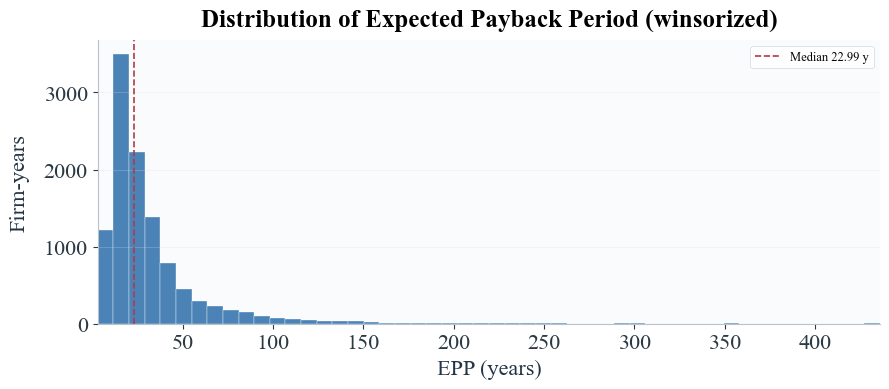


Correlations with EPP_w (expected: negative — short EPP = short duration = high BM/EP/SY):
  Corr(EPP_w, BM_w)       = -0.530
  Corr(EPP_w, EP_w)       = -0.149
  Corr(EPP_w, SY_gross_w) = -0.143


In [7]:
# ── EPP-Forecasting-Parameter ──────────────────────────────────
# Hardcodierte AR(1)-Parameter (nicht aus dem VAR des NP-Notebooks).
# Begründung: EPP ist ein robustheitsgetriebenes, diskontierungsfreies
# Maß. Einfache AR(1)-Mittelwertrückkehr ist hier ausreichend.
# Quelle: Dechow, Sloan & Soliman (2004), Table 1 (US-Kalibrierung).
# Für europäische Stichproben: konservativere Werte vertretbar.
#
# RHO_ROE = 0.57   → Persistenz der Eigenkapitalrendite
# RHO_G   = 0.24   → Persistenz des Buchwertswachstums
# ROE_BAR = 0.12   → Langfristige ROE (= angenommene Eigenkapitalkosten)
# G_BAR   = 0.06   → Langfristiges Buchwertswachstum
# H_EPP   = 10     → Maximaler expliziter Horizont (Jahre)
#
# THESIS TODO: Sensitivität gegenüber ROE_BAR = 0.08 / 0.10 / 0.12 prüfen.
# ───────────────────────────────────────────────────────────────
RHO_ROE = 0.57
RHO_G   = 0.24
ROE_BAR = 0.12
G_BAR   = 0.06
H_EPP   = 10


def _compute_epp_row(row):
    """
    AR(1) forecasts of ROE and BEG; EPP = interpolated crossing year.
    Returns (epp, flag_extrapolated).
    """
    me     = float(row["ME_t"])      if pd.notna(row["ME_t"])      else np.nan
    be_lag = float(row["BE_lag1"])   if pd.notna(row["BE_lag1"])   else np.nan
    be     = float(row["BE"])        if pd.notna(row["BE"])        else np.nan
    ni     = float(row["NetIncome"]) if pd.notna(row["NetIncome"]) else np.nan

    # Guard: require positive ME_t and positive BE_{t-1}
    if not (np.isfinite(me) and me > 0 and np.isfinite(be_lag) and be_lag > 0):
        return np.nan, np.nan

    if not np.isfinite(ni):
        return np.nan, np.nan

    roe0 = ni / be_lag
    beg0 = (be - be_lag) / be_lag if (np.isfinite(be) and np.isfinite(be_lag)) else G_BAR

    # AR(1) forecast paths (index 0 = current t; indices 1..H = forecast t+1..t+H)
    roe_path = np.empty(H_EPP + 1)
    beg_path = np.empty(H_EPP + 1)
    roe_path[0] = roe0
    beg_path[0] = beg0
    for h in range(1, H_EPP + 1):
        roe_path[h] = RHO_ROE * roe_path[h - 1] + (1.0 - RHO_ROE) * ROE_BAR
        beg_path[h] = RHO_G   * beg_path[h - 1] + (1.0 - RHO_G)   * G_BAR

    # Book-equity path: BE_h = BE_{h-1} * (1 + BEG_h), starting from BE_lag
    be_p = np.empty(H_EPP + 1)
    be_p[0] = be_lag
    for h in range(1, H_EPP + 1):
        be_p[h] = be_p[h - 1] * (1.0 + beg_path[h])

    # Annual cash flows: CF_h = BE_{h-1} * (ROE_h - BEG_h)
    cfs = np.array([be_p[h - 1] * (roe_path[h] - beg_path[h])
                    for h in range(1, H_EPP + 1)])

    cum_cf = np.cumsum(cfs)

    # Find first year h where cumulative CF >= ME_t
    reached = np.where(cum_cf >= me)[0]  # 0-indexed; year = index + 1

    if len(reached) == 0:
        # Linear extrapolation beyond H: EPP = H + (ME - cumCF_H) / CF_H
        cf_H = cfs[-1]
        if cf_H <= 0 or not np.isfinite(cf_H):
            return np.nan, True
        epp = H_EPP + (me - cum_cf[-1]) / cf_H
        return float(epp), True

    h_idx = reached[0]  # 0-indexed → year h_idx+1 (1-indexed)
    if h_idx == 0:
        # Crossed in first year: interpolate linearly between (0, 0) and (1, cum_cf[0])
        epp = float(me / cum_cf[0]) if cum_cf[0] > 0 else 1.0
        epp = min(epp, 1.0)
    else:
        cum_before = cum_cf[h_idx - 1]
        cum_after  = cum_cf[h_idx]
        denom = cum_after - cum_before
        if denom <= 0:
            return float(h_idx + 1), False
        epp = h_idx + (me - cum_before) / denom

    return float(epp), False


# --- Apply to all firm-years ---
_epp_out = ann.apply(_compute_epp_row, axis=1)
ann["EPP"]                   = [r[0] for r in _epp_out]
ann["flag_epp_extrapolated"] = pd.array([r[1] for r in _epp_out], dtype="boolean")

# --- Winsorize at 1%/99% by year ---
ann["EPP_w"] = _winsorize_cross_section(ann["EPP"], ann["year"])

# --- Descriptive statistics ---
n_epp    = int(ann["EPP"].notna().sum())
n_extrap = int(ann["flag_epp_extrapolated"].fillna(False).sum())
print(f"EPP non-null : {n_epp:,} ({100*n_epp/len(ann):.1f}%)")
print(f"Extrapolated (payback not reached within H={H_EPP}): "
      f"{n_extrap:,} ({100*n_extrap/max(n_epp, 1):.1f}%)")
print("\nEPP descriptive statistics:")
print(ann["EPP"].describe(percentiles=[.05, .1, .25, .5, .75, .9, .95]).round(2))
print("\nEPP_w descriptive statistics:")
print(ann["EPP_w"].describe(percentiles=[.05, .1, .25, .5, .75, .9, .95]).round(2))

# --- Distribution histogram ---
fig, ax = plt.subplots(figsize=(9, 4))
data_epp = ann["EPP_w"].dropna()
ax.hist(data_epp, bins=50, color=COLORS["blue"], edgecolor="white",
        linewidth=0.3, alpha=0.85)
ax.axvline(data_epp.median(), color=COLORS["accent"], linewidth=1.2,
           linestyle="--", label=f"Median {data_epp.median():.2f} y")
ax.set_title("Distribution of Expected Payback Period (winsorized)")
ax.set_xlabel("EPP (years)")
ax.set_ylabel("Firm-years")
style_axes(ax)
ax.legend(fontsize=9)
plt.tight_layout()
save_figure(fig, "epp_distribution")
plt.show()

# --- Correlations with other duration proxies ---
# Expected: negative — short EPP = short duration = high BM/EP/SY
_corr_epp = ann[["EPP_w", "BM_w", "EP_w", "SY_gross_w"]].dropna()
print("\nCorrelations with EPP_w "
      "(expected: negative — short EPP = short duration = high BM/EP/SY):")
print(f"  Corr(EPP_w, BM_w)       = {_corr_epp['EPP_w'].corr(_corr_epp['BM_w']):.3f}")
print(f"  Corr(EPP_w, EP_w)       = {_corr_epp['EPP_w'].corr(_corr_epp['EP_w']):.3f}")
print(f"  Corr(EPP_w, SY_gross_w) = {_corr_epp['EPP_w'].corr(_corr_epp['SY_gross_w']):.3f}")

## 5. Quality Screens & Sample Diagnostics

In [8]:
N0 = len(ann)
print(f"Starting sample: {N0:,} firm-years")
print()

screens = [
    ("ME_t > 0",           ann["ME_t"].notna() & (ann["ME_t"] > 0)),
    ("BE > 0",             be.notna() & (be > 0)),
    ("Finite NetIncome",   ni.notna() & np.isfinite(ni)),
    ("≥1 measure valid",   ann["SY_gross"].notna() | ann["SY_div_only"].notna() | ann["BM"].notna() | ann["EP"].notna()),
]

mask = pd.Series(True, index=ann.index)
rows = []
for label, condition in screens:
    before = mask.sum()
    mask = mask & condition
    after = mask.sum()
    rows.append({"Screen": label, "Before": before, "After": after, "Dropped": before - after})

screen_df = pd.DataFrame(rows)
print(screen_df.to_string(index=False))
print(f"\nFinal analytic sample: {mask.sum():,} firm-years")

# By-year coverage
print("\nBy-year non-null counts:")
coverage = ann.groupby("year")[["SY_gross", "SY_div_only", "BM", "EP"]].count()
print(coverage.to_string())
print("\nNote: SY_div_only coverage < SY_gross coverage because SY_div_only"
      "\n      requires Dividends to be non-null, while SY_gross is non-null whenever"
      "\n      either Dividends or Buybacks are available (fill_value=0).")

# By-sector if available
sector_col = next((c for c in ["sector", "Sector", "gics_sector", "industry"] if c in ann.columns), None)
if sector_col:
    print(f"\nBy-sector coverage ({sector_col}):")
    sec_cov = ann.groupby(sector_col)[["SY_gross", "SY_div_only", "BM", "EP"]].count()
    print(sec_cov.to_string())
else:
    print("\n[INFO] No sector column found – skipping sector breakdown.")

Starting sample: 12,073 firm-years

          Screen  Before  After  Dropped
        ME_t > 0   12073  11692      381
          BE > 0   11692  11571      121
Finite NetIncome   11571  11541       30
≥1 measure valid   11541  11541        0

Final analytic sample: 11,541 firm-years

By-year non-null counts:
      SY_gross  SY_div_only   BM   EP
year                                 
1997       183          168  281  284
1998       255          233  385  389
1999       316          279  411  414
2000       354          302  428  432
2001       318          283  390  394
2002       318          286  388  392
2003       345          313  413  411
2004       386          355  406  412
2005       403          366  412  417
2006       410          375  418  421
2007       417          383  425  425
2008       409          382  415  422
2009       410          389  419  419
2010       423          398  431  432
2011       421          400  420  428
2012       411          395  418  423
2013   

## 6. Correlation Matrix & Validation

In [9]:
measures = ["SY_gross_w", "SY_div_only_w", "BM_w", "EP_w"]
corr_df = ann[measures].dropna()

pearson  = corr_df.corr(method="pearson")
spearman = corr_df.corr(method="spearman")

print("Pearson correlation:")
print(pearson.round(3).to_string())
print("\nSpearman rank correlation:")
print(spearman.round(3).to_string())

# Flag redundant pairs
print("\nRedundancy check (|Pearson| > 0.8):")
found = False
for i, c1 in enumerate(measures):
    for c2 in measures[i+1:]:
        v = abs(pearson.loc[c1, c2])
        if v > 0.8:
            print(f"  [WARN] {c1} vs {c2}: r = {v:.3f}")
            found = True
if not found:
    print("  None – no pair exceeds 0.8.")

Pearson correlation:
               SY_gross_w  SY_div_only_w   BM_w   EP_w
SY_gross_w          1.000          0.521  0.275  0.093
SY_div_only_w       0.521          1.000  0.366  0.158
BM_w                0.275          0.366  1.000  0.136
EP_w                0.093          0.158  0.136  1.000

Spearman rank correlation:
               SY_gross_w  SY_div_only_w   BM_w   EP_w
SY_gross_w          1.000          0.763  0.315  0.270
SY_div_only_w       0.763          1.000  0.342  0.323
BM_w                0.315          0.342  1.000  0.299
EP_w                0.270          0.323  0.299  1.000

Redundancy check (|Pearson| > 0.8):
  None – no pair exceeds 0.8.


Saved figure: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/graphs/EQDuration_Robustness/correlation_matrix_measures.png


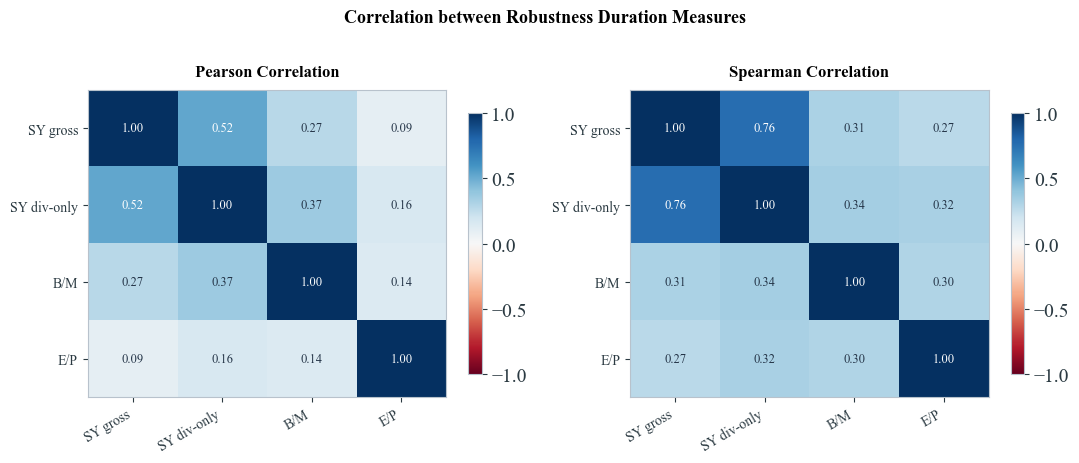

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
labels = ["SY gross", "SY div-only", "B/M", "E/P"]

for ax, mat, title in zip(axes, [pearson, spearman], ["Pearson", "Spearman"]):
    im = ax.imshow(mat.values, vmin=-1, vmax=1, cmap="RdBu", aspect="auto")
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, fontsize=10, rotation=30, ha="right")
    ax.set_yticklabels(labels, fontsize=10)
    ax.set_title(f"{title} Correlation", fontsize=12, fontweight="semibold")
    for i in range(len(labels)):
        for j in range(len(labels)):
            val = mat.values[i, j]
            ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                    fontsize=9, color="white" if abs(val) > 0.5 else "#243447")
    plt.colorbar(im, ax=ax, shrink=0.85)

plt.suptitle("Correlation between Robustness Duration Measures", y=1.02, fontsize=13, fontweight="semibold")
plt.tight_layout()
save_figure(fig, "correlation_matrix_measures")
plt.show()

Saved figure: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/graphs/EQDuration_Robustness/duration_proxies_timeseries.png


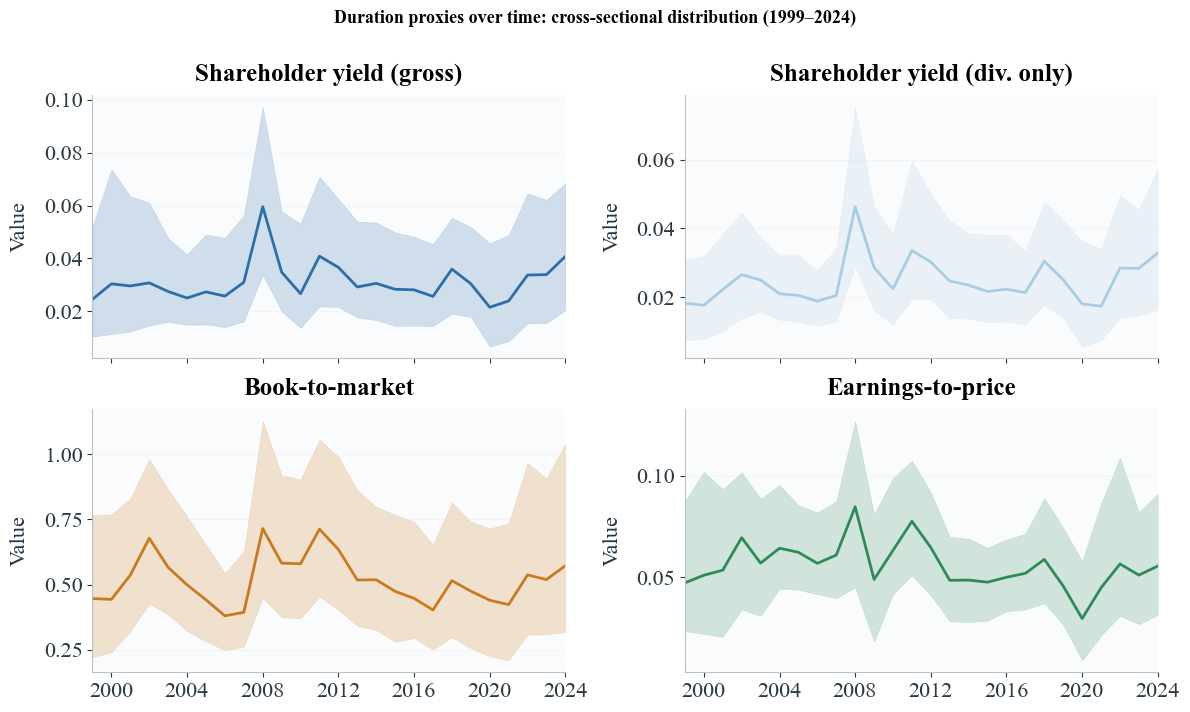

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
axes = axes.flatten()

measures_plot = [
    ("SY_gross_w",    "Shareholder yield (gross)",      COLORS["blue"]),
    ("SY_div_only_w", "Shareholder yield (div. only)",  COLORS["blue_light"]),
    ("BM_w",          "Book-to-market",                 COLORS["orange"]),
    ("EP_w",          "Earnings-to-price",              COLORS["green"]),
]

for ax, (col, label, color) in zip(axes, measures_plot):
    _yr = ann.groupby("year")[col].agg(
        p25=lambda x: x.quantile(0.25),
        p50="median",
        p75=lambda x: x.quantile(0.75),
    )
    _yr = _yr.loc[(_yr.index >= 1999) & (_yr.index <= 2024)]

    ax.fill_between(_yr.index, _yr["p25"], _yr["p75"],
                    alpha=0.2, color=color)
    ax.plot(_yr.index, _yr["p50"], color=color, lw=2,
            label="Median")
    ax.set_title(label)
    ax.set_ylabel("Value")
    ax.set_xticks(range(2000, 2025, 4))
    style_axes(ax)

fig.suptitle("Duration proxies over time: cross-sectional distribution (1999–2024)",
             y=1.01, fontsize=13, fontweight="semibold")
plt.tight_layout()
save_figure(fig, "duration_proxies_timeseries")
plt.show()

Saved figure: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/graphs/EQDuration_Robustness/coverage_robustness_measures.png


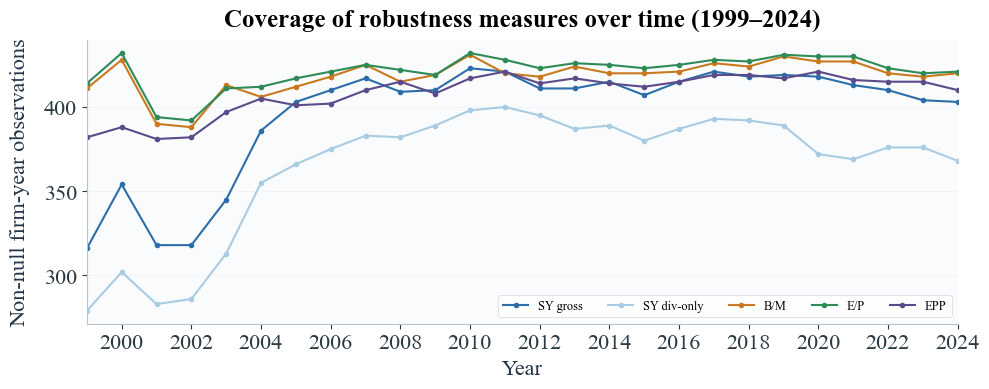

In [12]:
fig, ax = plt.subplots(figsize=(10, 4))

_cov = ann.groupby("year")[
    ["SY_gross", "SY_div_only", "BM", "EP", "EPP"]
].count()
_cov = _cov.loc[(_cov.index >= 1999) & (_cov.index <= 2024)]

colors_cov = [COLORS["blue"], COLORS["blue_light"],
              COLORS["orange"], COLORS["green"], COLORS["purple"]]
labels_cov = ["SY gross", "SY div-only", "B/M", "E/P", "EPP"]

for col, color, label in zip(
    ["SY_gross","SY_div_only","BM","EP","EPP"],
    colors_cov, labels_cov
):
    ax.plot(_cov.index, _cov[col], color=color, lw=1.5,
            marker="o", ms=3, label=label)

ax.set_xlabel("Year")
ax.set_ylabel("Non-null firm-year observations")
ax.set_title("Coverage of robustness measures over time (1999–2024)")
ax.set_xticks(range(2000, 2025, 2))
ax.legend(frameon=True, ncol=5, loc="lower right", fontsize=9)
style_axes(ax)
plt.tight_layout()
save_figure(fig, "coverage_robustness_measures")
plt.show()

Saved figure: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/graphs/EQDuration_Robustness/scatter_matrix_duration_proxies.png


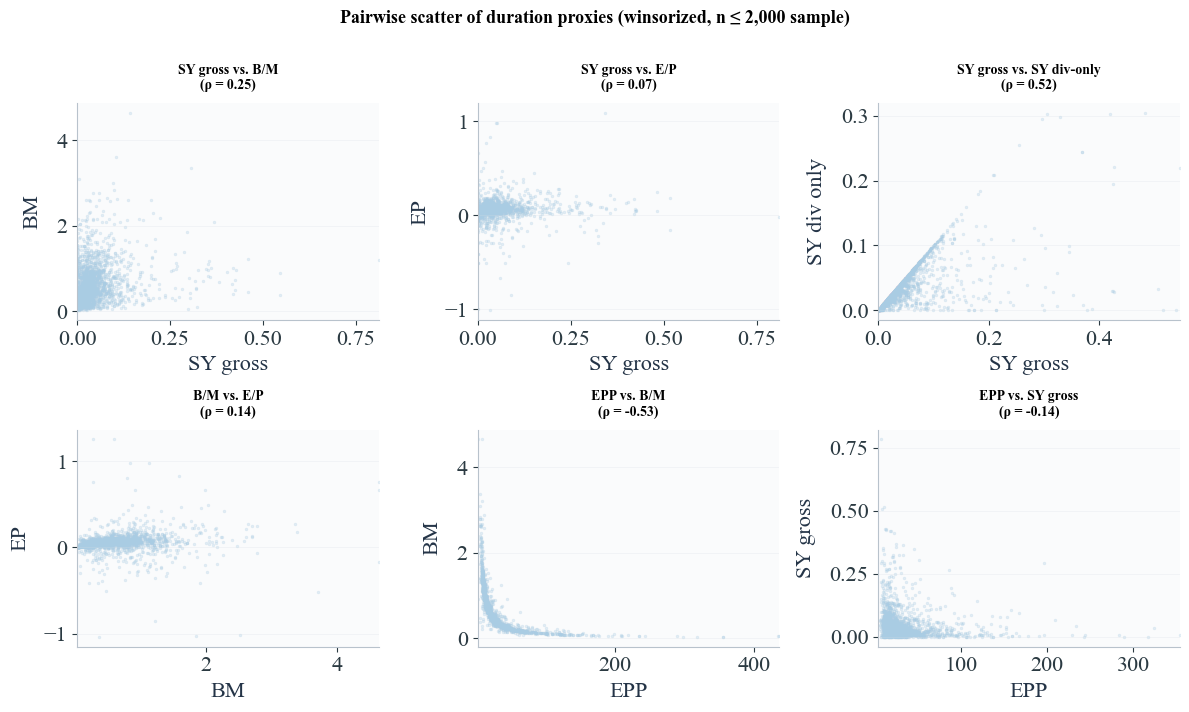

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
pairs = [
    ("SY_gross_w",    "BM_w",          "SY gross vs. B/M"),
    ("SY_gross_w",    "EP_w",          "SY gross vs. E/P"),
    ("SY_gross_w",    "SY_div_only_w", "SY gross vs. SY div-only"),
    ("BM_w",          "EP_w",          "B/M vs. E/P"),
    ("EPP_w",         "BM_w",          "EPP vs. B/M"),
    ("EPP_w",         "SY_gross_w",    "EPP vs. SY gross"),
]
for ax, (x, y, title) in zip(axes.flatten(), pairs):
    _d = ann[[x, y]].dropna()
    _sample = _d.sample(min(2000, len(_d)), random_state=42)
    ax.scatter(_sample[x], _sample[y], s=4, alpha=0.3,
               color=COLORS["blue_light"])
    _r = _d[x].corr(_d[y])
    ax.set_title(f"{title}\n(ρ = {_r:.2f})", fontsize=10)
    ax.set_xlabel(x.replace("_w","").replace("_"," "))
    ax.set_ylabel(y.replace("_w","").replace("_"," "))
    style_axes(ax)

plt.suptitle("Pairwise scatter of duration proxies (winsorized, n ≤ 2,000 sample)",
             y=1.01, fontsize=13, fontweight="semibold")
plt.tight_layout()
save_figure(fig, "scatter_matrix_duration_proxies")
plt.show()

Saved figure: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/graphs/EQDuration_Robustness/epp_timeseries.png


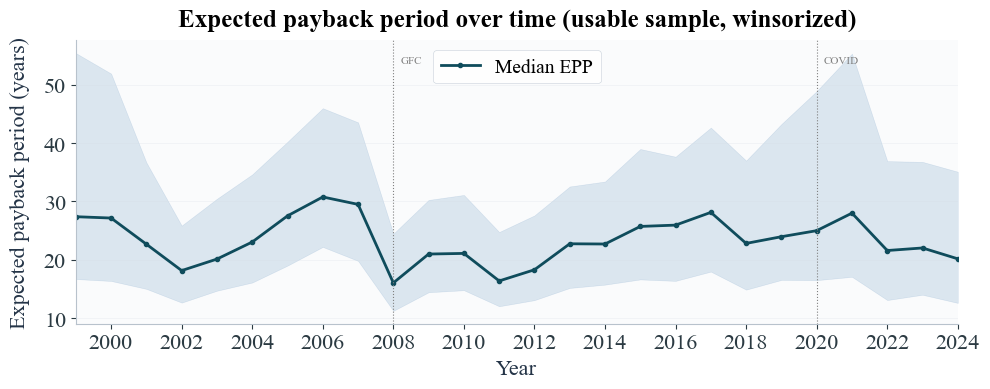

In [14]:
fig, ax = plt.subplots(figsize=(10, 4))

_epp_yr = ann.groupby("year")["EPP_w"].agg(
    p25=lambda x: x.quantile(0.25),
    p50="median",
    p75=lambda x: x.quantile(0.75),
).loc[lambda d: (d.index >= 1999) & (d.index <= 2024)]

ax.fill_between(_epp_yr.index, _epp_yr["p25"], _epp_yr["p75"],
                alpha=0.15, color=COLORS["blue"])
ax.plot(_epp_yr.index, _epp_yr["p50"],
        color=COLORS["primary"], lw=2, marker="o", ms=3,
        label="Median EPP")

for yr, lbl in [(2008, "GFC"), (2020, "COVID")]:
    ax.axvline(yr, color="gray", lw=0.8, ls=":")
    ax.text(yr + 0.2, _epp_yr["p75"].max() * 0.97,
            lbl, fontsize=8, color="gray")

ax.set_xlabel("Year")
ax.set_ylabel("Expected payback period (years)")
ax.set_title("Expected payback period over time (usable sample, winsorized)")
ax.set_xticks(range(2000, 2025, 2))
ax.legend(frameon=True)
style_axes(ax)
plt.tight_layout()
save_figure(fig, "epp_timeseries")
plt.show()

## 7. Save Output

In [15]:
output_cols = [
    "firm_id", "year", "ME_t",
    # Raw measures
    "SY_gross", "SY_div_only", "BM", "EP", "EPP",
    # Winsorized
    "SY_gross_w", "SY_div_only_w", "BM_w", "EP_w", "EPP_w",
    # Flags
    "flag_sy_negative", "flag_sy_buybacks_missing", "flag_epp_extrapolated",
]

out = ann[[c for c in output_cols if c in ann.columns]].copy()

out["n_measures_available"] = (
    out[["SY_gross", "BM", "EP", "EPP"]]
    .notna()
    .sum(axis=1)
    .astype("Int8")
)

out = out.sort_values(["firm_id", "year"]).reset_index(drop=True)

save_parquet(out, "EQDuration_Robustness")

print(f"\nFinal shape: {out.shape}")
print(f"Columns: {list(out.columns)}")
print("\nNon-null coverage:")
for col in ["SY_gross", "SY_div_only", "BM", "EP", "EPP",
            "SY_gross_w", "SY_div_only_w", "BM_w", "EP_w", "EPP_w"]:
    if col in out.columns:
        n = out[col].notna().sum()
        print(f"  {col:<16} {n:>6,}  ({100*n/len(out):.1f}%)")
print(f"\nFlag coverage:")
print(f"  flag_sy_buybacks_missing:  "
      f"{out['flag_sy_buybacks_missing'].sum():,} obs")
print(f"  flag_epp_extrapolated:     "
      f"{int(out['flag_epp_extrapolated'].fillna(False).sum()):,} obs")

Saved: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/intermediate/EQDuration_Robustness.parquet

Final shape: (12073, 17)
Columns: ['firm_id', 'year', 'ME_t', 'SY_gross', 'SY_div_only', 'BM', 'EP', 'EPP', 'SY_gross_w', 'SY_div_only_w', 'BM_w', 'EP_w', 'EPP_w', 'flag_sy_negative', 'flag_sy_buybacks_missing', 'flag_epp_extrapolated', 'n_measures_available']

Non-null coverage:
  SY_gross         10,764  (89.2%)
  SY_div_only       9,913  (82.1%)
  BM               11,571  (95.8%)
  EP               11,658  (96.6%)
  EPP              10,936  (90.6%)
  SY_gross_w       10,764  (89.2%)
  SY_div_only_w     9,913  (82.1%)
  BM_w             11,571  (95.8%)
  EP_w             11,658  (96.6%)
  EPP_w            10,936  (90.6%)

Flag coverage:
  flag_sy_buybacks_missing:  3,214 obs
  flag_epp_extrapolated:     10,308 obs


In [16]:
print("=== ROBUSTNESS NOTEBOOK — FINAL CHECK ===")
print(f"Sample (nach Financials-Filter): {len(ann):,} firm-years")
print(f"Firms: {ann['firm_id'].nunique():,}")
print()
for col in ["SY_gross_w","SY_div_only_w","BM_w","EP_w","EPP_w"]:
    n = ann[col].notna().sum()
    print(f"  {col:<20s} {n:>6,}  ({100*n/len(ann):.1f}%)")
print()
saved = list((GRAPH_SUBDIR).glob("*.png"))
print(f"Gespeicherte Grafiken ({len(saved)}):")
for f in sorted(saved):
    print(f"  {f.name}")

=== ROBUSTNESS NOTEBOOK — FINAL CHECK ===
Sample (nach Financials-Filter): 12,073 firm-years
Firms: 946

  SY_gross_w           10,764  (89.2%)
  SY_div_only_w         9,913  (82.1%)
  BM_w                 11,571  (95.8%)
  EP_w                 11,658  (96.6%)
  EPP_w                10,936  (90.6%)

Gespeicherte Grafiken (14):
  correlation_matrix_measures.png
  correlation_matrix_measures_beamer.png
  coverage_robustness_measures.png
  coverage_robustness_measures_beamer.png
  duration_proxies_timeseries.png
  duration_proxies_timeseries_beamer.png
  epp_distribution.png
  epp_distribution_beamer.png
  epp_timeseries.png
  epp_timeseries_beamer.png
  scatter_matrix_duration_proxies.png
  scatter_matrix_duration_proxies_beamer.png
  sy_distribution.png
  sy_distribution_beamer.png


## 8. Interpretation

### What was computed

Three firm-level proxies for **equity duration** were constructed from annual accounting and
market-cap data for the Euro 500 universe:

| Measure | Formula | Duration interpretation |
|---------|---------|------------------------|
| **SY gross** | (Dividends + Buybacks) / ME | High SY → near-term cash flows → **short** duration |
| **SY div-only** | Dividends / ME | Higher coverage; preferred when buyback data is sparse |
| **B/M** | BE / ME | Value (high B/M) → short duration; growth (low B/M) → long duration |
| **E/P** | NetIncome / ME | Earnings yield; high E/P → current profits dominate → short duration |

All measures are winsorized at 1%/99% cross-sectionally within each year.

### Expected economic signs

- **SY and B/M**: positively correlated — value firms tend to return more cash; both proxy
  short duration (consistent with DSS and Lettau & Wachter).
- **SY and E/P**: positively correlated — profitable firms pay out more.
- **B/M and E/P**: positively correlated in levels (value firms tend to be currently profitable).
- All should be **negatively** correlated with implied/long-horizon duration measures.

### Cross-sectional variation

B/M typically shows the widest cross-sectional dispersion because it reflects cumulative
retained earnings vs. market expectations of future growth. E/P is compressed by loss firms.
SY variants are mechanically bounded near zero for most firms but show meaningful
right-tail variation driven by large repurchasers. `SY_div_only` offers the widest
coverage and is recommended as the primary SY measure.

### Merge readiness

The output table `EQDuration_Robustness.parquet` contains one row per `(firm_id, year)` and
merges directly into the ECB shock regression panel via:

```python
panel.merge(robustness, on=["firm_id", "year"], how="left")
```

Use winsorized variants (`*_w`) in regressions. `SY_div_only_w` is recommended as the
primary SY measure when buyback coverage is a concern.